### [ 주제: 붓꽃의 품종 분류 ] <hr>

- 학습 종류: 지도 학습
- 학습 방법: 분류 관련 모델 중에서 선택
- 데이터: iris.csv
- 구현 단계
    * (1) 데이터 준비 및 확인
    * (2) 데이터 전처리
    * (3) 학습/ 검증/ 테스트용 데이터셋 분리
    * (4) 학습
    * (5) 평가

- **[0] 모듈 로딩**

In [39]:
## -------------------------------------
## 이미지 데이터 로딩 & 기본 정보
## -------------------------------------
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import matplotlib.cm as cm
import sys
sys.path.append(r"C:\KDT14\7_CV")

import importlib
import cv_utils

importlib.reload(cv_utils)

from sklearn.model_selection import train_test_split #학습용| 테스트용 데이터 분할
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier # 모델클래스
from sklearn.metrics import accuracy_score, classification_report # 평가
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate

- **[1] 데이터 준비 및 확인**

In [4]:
DATA_FILE= './iris.csv'

dataDF= pd.read_csv(DATA_FILE)

In [14]:
## 데이터 기본 정보 확인=> 형태, 컬럼(타입, 결측치 여부, 개수), 실제 데이터와 비교, 컬럼별 통계치
dataDF.info()
display(dataDF.head(3))
dataDF.describe() # 통계치
dataDF.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa


,sepal.length,sepal.width,petal.length,petal.width,variety
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,Setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


In [15]:
## [ 1차 해석 ]
## - variety 컬럼: str==> category 형변환
## - 결측치: 없음
## - 타겟/ 라벨/ 클래스 컬럼: variety
## - 피쳐/ 특성/ 속성 컬럼: sepal/length, sepal.width, petal.length, petal.width

- **[2]데이터 전처리**

In [18]:
## variety 컬럼 : str == > category 형변환
## - df.astype으로 자료형 변환: inplace 매개변수x. 반드시 저장

dataDF.variety= dataDF.variety.astype('category')

display(dataDF.dtypes)

sepal.length     float64
sepal.width      float64
petal.length     float64
petal.width      float64
variety         category
dtype: object

- **[3]학습용/ 검증용/ 테스트용 데이터셋 준비**

In [21]:
## 피처와 타겟 분리
featureDF= dataDF[dataDF.columns[:-1]]
targetSR= dataDF[dataDF.columns[-1]]

print(f'피처: {featureDF.shape}, 타겟: {targetSR.shape}')

피처: (150, 4), 타겟: (150,)


In [24]:
## => 학습용 |테스트용 분리 : 분류 => 타겟 클래스 비율 유지 stratify 매개변수 설정
#                          재현성 => random_state 매개변수 설정
#                          피처 차원-> 2차원
#                          타겟 차원-> 1차원



X_train, X_test, y_train, y_test= train_test_split(featureDF, targetSR, test_size=0.2, random_state= 10, stratify= targetSR)

In [33]:
## => 확인
print(f'학습용 : {X_train.shape}, {y_train.shape} 테스트용 : {X_test.shape}, {y_test.shape}')
print(f'클래스 데이터 구성\n', y_train.value_counts().tolist())
print(f'\n테스트 데이터 구성\n', y_test.value_counts().tolist())


학습용 : (120, 4), (120,) 테스트용 : (30, 4), (30,)
클래스 데이터 구성
 [40, 40, 40]

테스트 데이터 구성
 [10, 10, 10]


- **[4] 교차검증**

In [ ]:
## -> 모델 인스턴스, 학습용 데이터, 학습용 정답

## -> 모델 인스턴스: KNN
kModel= KNeighborsClassifier()

# cross_val_score=> 교차검증 평가 점수
val_scores= cross_val_score(kModel, X_train, y_train)
print(f'검증데이터 평가점수: {val_scores} 평균 점수:{val_scores.mean()}')

검증데이터 평가점수: [0.95833333 0.875      0.91666667 1.         0.95833333] 평균 점수:0.9416666666666667


In [41]:

## => cross_validate 함수: 교차검증 검증데이터 평가 점수
all_scores= cross_validate(kModel, X_train, y_train, return_train_score=True)

scoreDF= pd.DataFrame(all_scores)
scoreDF

,fit_time,score_time,test_score,train_score
0,0.002009,0.002999,0.958333,0.979167
1,0.002763,0.003010,0.875000,0.989583
2,0.001508,0.002054,0.916667,0.979167
3,0.001009,0.002002,1.000000,0.968750
4,0.001000,0.003009,0.958333,0.979167


In [46]:
## 교차검증 결과 저장

scoreDF= pd.DataFrame(all_scores)

scoreDF['GAP'] = abs(scoreDF['train_score']- scoreDF['test_score'])
scoreDF.loc['AVG']= [scoreDF[col].mean() for col in scoreDF.columns]

display('[종합평가]')
print(f'k=5 일 때 학습 점수와 테스트 점수 평균 차이: {scoreDF.loc["AVG", "GAP"]:.4f}')




'[종합평가]'

k=5 일 때 학습 점수와 테스트 점수 평균 차이: 0.0500


- **[5] 성능 향상 위한 K 찾기**
    * 모델 성능에 영향을 미치는 파라미터: 하이퍼 파라미터(Hyper Parameter)
    * 모델마다 개수도 다르고, 종류 다름

In [61]:
## => KNN : K - 모델 성능 좌우
##    K값을 변경하면서 평균 모델 성능 체크
##    K값 범위 : 1 ~ 전체데이터수 -1/ 홀수 사용



totalDict = {'K':[], 'train_score':[], 'test_score':[]}

for k in range(1, 50, 2):
    ## => 모델인스턴스 : KNN
    kModel = KNeighborsClassifier(n_neighbors=k)
    
    ## => 교차검증
    resultDict = cross_validate(kModel, X_train, y_train, return_train_score=True)
    

    ## => K, 평균 학습 점수, 평균 검증 점수
    totalDict['K'].append(k)
    totalDict['train_score'].append(resultDict['train_score'].mean())
    totalDict['test_score'].append(resultDict['test_score'].mean())
    print(totalDict)

    # ## => 학습 점수, 검증 점수
    # print(resultDict['train_score'].mean(), resultDict['test_score'].mean())
  

    # break
totalDF = pd.DataFrame(totalDict)

{'K': [1], 'train_score': [np.float64(1.0)], 'test_score': [np.float64(0.95)]}
{'K': [1, 3], 'train_score': [np.float64(1.0), np.float64(0.95625)], 'test_score': [np.float64(0.95), np.float64(0.9416666666666667)]}
{'K': [1, 3, 5], 'train_score': [np.float64(1.0), np.float64(0.95625), np.float64(0.9791666666666666)], 'test_score': [np.float64(0.95), np.float64(0.9416666666666667), np.float64(0.9416666666666667)]}
{'K': [1, 3, 5, 7], 'train_score': [np.float64(1.0), np.float64(0.95625), np.float64(0.9791666666666666), np.float64(0.96875)], 'test_score': [np.float64(0.95), np.float64(0.9416666666666667), np.float64(0.9416666666666667), np.float64(0.9583333333333334)]}
{'K': [1, 3, 5, 7, 9], 'train_score': [np.float64(1.0), np.float64(0.95625), np.float64(0.9791666666666666), np.float64(0.96875), np.float64(0.9708333333333332)], 'test_score': [np.float64(0.95), np.float64(0.9416666666666667), np.float64(0.9416666666666667), np.float64(0.9583333333333334), np.float64(0.95)]}
{'K': [1, 3, 5,

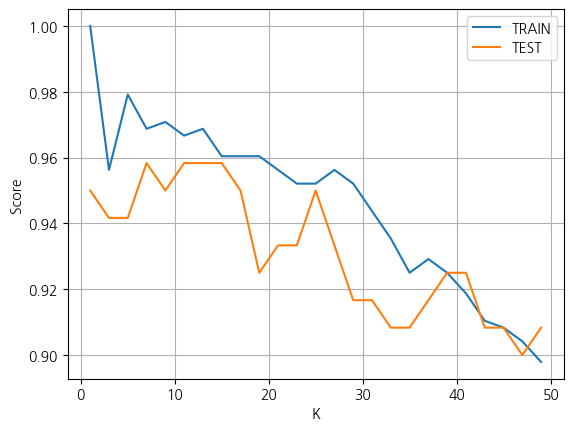

In [63]:
totalDF= pd.DataFrame(totalDict)

## 학습-검증 차이가 가장 작은 K
gabSR = abs(totalDF['train_score'] - totalDF['test_score'])
gabSR.sort_values()

plt.plot(totalDF['K'], totalDF['train_score'], label= ['TRAIN'])
plt.plot(totalDF['K'], totalDF['test_score'], label= ['TEST'])
plt.legend()
plt.xlabel("K")
plt.ylabel("Score")
plt.grid()
plt.show()

In [65]:
gabSR.sort_values()

## 학습-검증 차이가 가장 작은 K
totalDF['Abs_Gab' ] = abs(totalDF['train_score' ] - totalDF['test_score' ])
totalDF.sort_values(by=['test_score'], ascending=False)

,K,train_score,test_score,Abs_Gab
3,7,0.968750,0.958333,0.010417
6,13,0.968750,0.958333,0.010417
7,15,0.960417,0.958333,0.002083
5,11,0.966667,0.958333,0.008333
0,1,1.000000,0.950000,0.050000
4,9,0.970833,0.950000,0.020833
8,17,0.960417,0.950000,0.010417
12,25,0.952083,0.950000,0.002083
1,3,0.956250,0.941667,0.014583
2,5,0.979167,0.941667,0.037500


In [66]:
## K값에 따른 성능 비교
totalDF = pd. DataFrame(totalDict)

## 학습-검증 차이가 가장 작은 K
totalDF['Abs_Gab' ] = abs(totalDF['train_score' ] - totalDF['test_score' ])
sortDF = totalDF.sort_values(by=['test_score', 'Abs_Gab'], ascending=[False, True], ignore_index=True)

## 최고 성능 K, 최고 점수
best_k, best_score = sortDF.iloc[0]['K'], sortDF.iloc[0]['test_score']
min_y, max_y = totalDF['train_score' ].min() , totalDF['train_score' ]. max( )

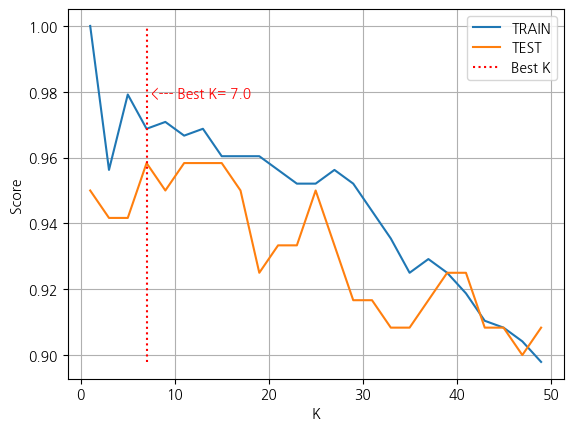

In [71]:
## 학습 점수, 검증 점수 그래프
plt.plot(totalDF['K'], totalDF['train_score'], label = ['TRAIN' ])
plt.plot(totalDF['K'], totalDF['test_score'], label = ['TEST' ])

## 베스트 K
plt.vlines(best_k, min_y, max_y, colors='red', linestyles='dotted', label='Best K')
plt.text(best_k, best_score+0.02, f' <--- Best K= {best_k}', c ='red')

## 그래프 설정
plt.legend()
plt.xlabel("K")
plt.ylabel("Score")
plt.grid()
plt.show()
